# Model of the thrust of the Windracers vehicle during taxi


$ T = c_t  \omega^2$

$\dot{\omega} = (\omega_c - \omega) / \tau$

$s \omega = (\omega_c - \omega) / \tau $

$ (s + 1/\tau) \omega = \omega_c/ \tau$

$ (\tau s + 1) \omega = \omega_c$

$\dfrac{\omega}{\omega_c} = \dfrac{1}{\tau s + 1}$


In [1]:
import casadi as ca
import numpy as np
import time
from corti.bezier_rover_planning import generate_path
from corti.rover_planning import RoverPlanner
from NightVaporMPC import *

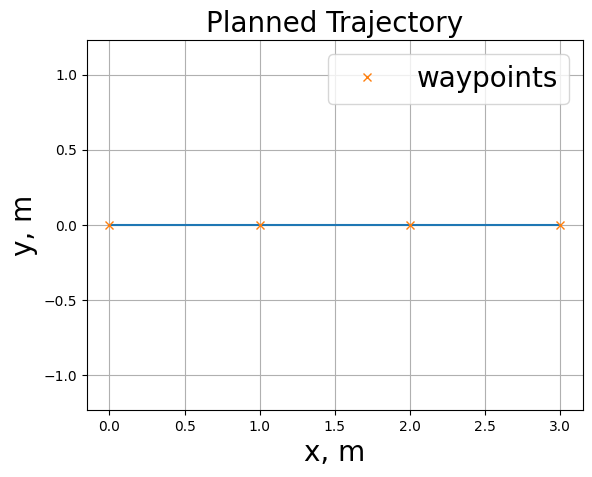

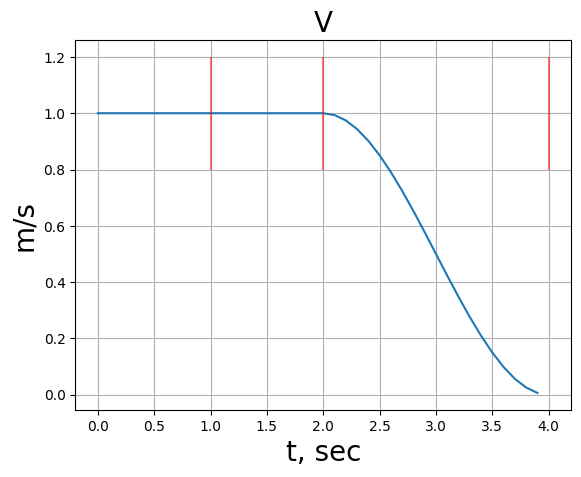

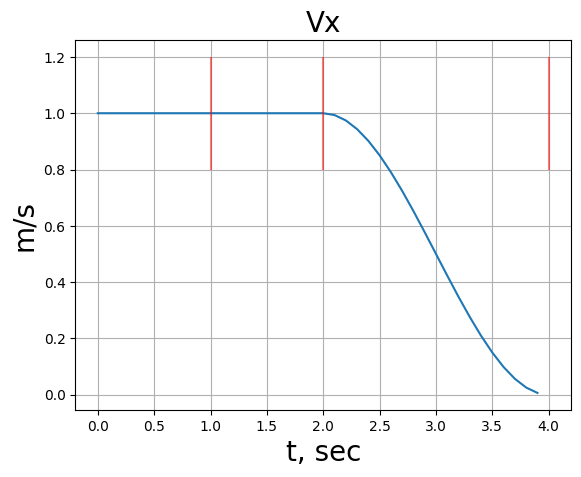

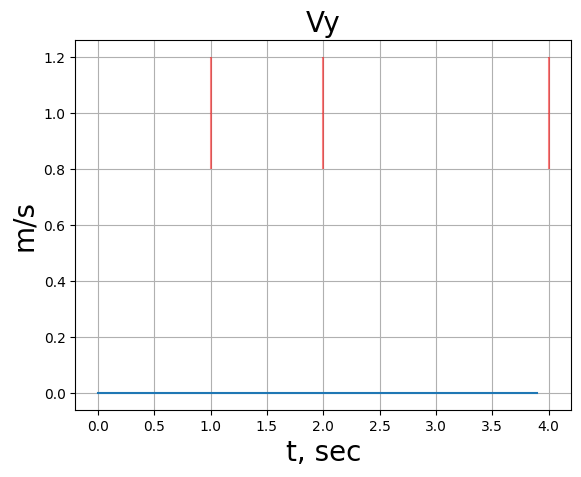

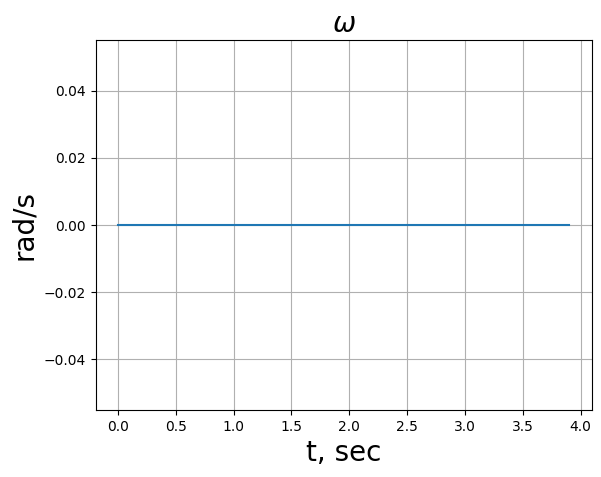

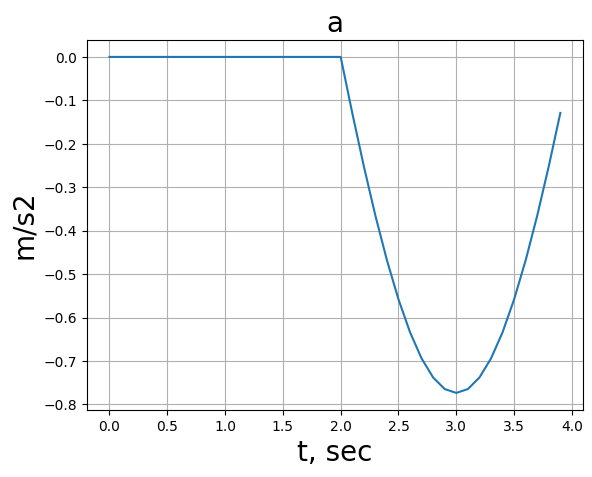

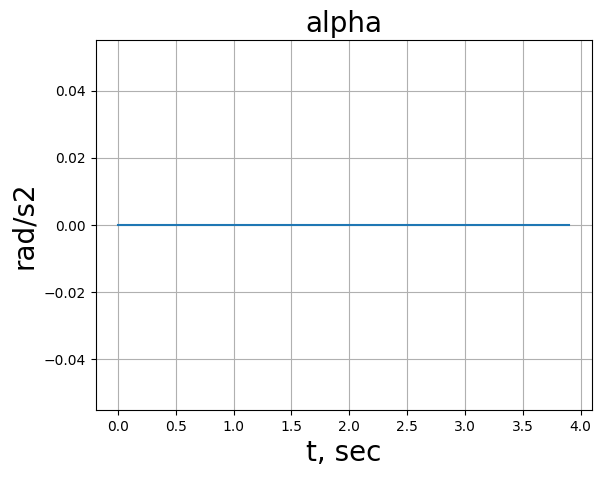

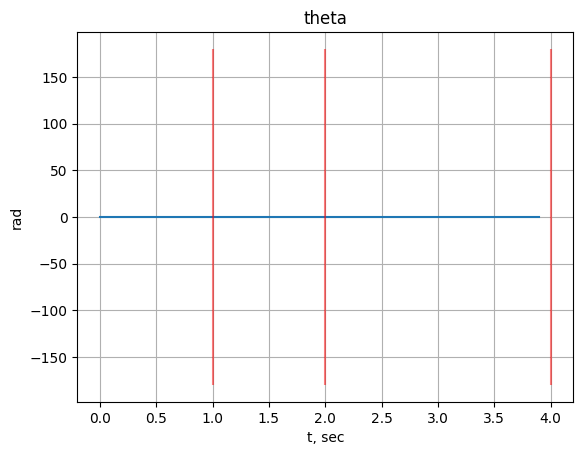

In [13]:
v  = 1
r = 1
planner = RoverPlanner(x=0, y=0, v=v, theta=0, r=r)
planner.goto(3, 0, v, r)
# planner.goto(3, 6, v, r)
# planner.goto(0, 6, v, r)
# planner.goto(0, 0, v, r)
# planner.goto(-3, 0, v, r)
# planner.goto(-3, 3, v, r)
# planner.goto(0, 3, v, r)
# planner.goto(0, 6, v, r)
# planner.goto(3, 6, v, r)
# planner.goto(3, 3, v, r)
# planner.goto(-3, 3, v, r)
# planner.goto(-3, 6, v, r)
planner.stop(3, 0)

ref_data = planner.compute_ref_data(plot=True)
t = ref_data['t']
xt = np.array([ref_data['x'](t), ref_data['y'](t), ref_data['theta'](t)]).T

In [19]:
eqs = derive_dynamics()

N = 15
dt = 1
nlp = nlp_multiple_shooting(eqs,N,dt)
solver = ca.nlpsol('solver', 'ipopt', nlp['nlp_prob'], nlp['opts'])

n_x = nlp['n_x']
n_u = nlp['n_u']

v_max = 1
r_c_max = 1
v_min = -1
r_c_min = -r_c_max
lbg = ca.DM.zeros((n_x * (N+1)))
ubg = -ca.DM.zeros((n_x * (N+1)))

lbx = ca.DM.zeros((n_x * (N + 1) + n_u * N, 1))
ubx = ca.DM.zeros((n_x * (N + 1) + n_u * N, 1))

# states x: [w, r, vx, vy, omega, px, py, theta]
lbx[0:n_x * (N + 1):n_x] = -ca.inf
lbx[1:n_x * (N + 1):n_x] = -ca.inf
lbx[2:n_x * (N + 1):n_x] = -ca.inf

ubx[0:n_x * (N + 1):n_x] = ca.inf
ubx[1:n_x * (N + 1):n_x] = ca.inf
ubx[2:n_x * (N + 1):n_x] = ca.inf

lbx[n_x*(N + 1)::n_u] = v_min
ubx[n_x*(N + 1)::n_u] = v_max
lbx[n_x*(N + 1)+1::n_u] = r_c_min
ubx[n_x*(N + 1)+1::n_u] = r_c_max



args = {
    'lbg': lbg,
    'ubg': ubg,
    'lbx': lbx,
    'ubx': ubx,
}

In [20]:
u0 = ca.DM.zeros((n_u, N))

x0 = ca.DM.zeros(n_x, 1)

# parameters p: [tau_w, tau_r, c_t, m, J_z, rho, S]
p = ca.vertcat(1)

mpc_iter = 0

X0 = ca.repmat(x0, 1, (N + 1))
cat_states = np.array(X0.full())
cat_controls = np.array(u0[:, 0])
times = np.array([[0]])

for i in range(xt.shape[0]):
    t1 = time.time()
    args['P'] = ca.vertcat(p, update_param(x0, xt, i, N))
    # print(args['P'])

    args['x0'] = ca.vertcat(ca.reshape(X0, n_x * (N + 1), 1),
                            ca.reshape(u0, n_u * N, 1))

    sol = solver(x0=args['x0'], lbx=args['lbx'], ubx=args['ubx'],
                 lbg=args['lbg'], ubg=args['ubg'], p=args['P'])
    u = ca.reshape(sol['x'][n_x * (N + 1):], n_u, N)
    # print('control',u[:,0])
    X = ca.reshape(sol['x'][:n_x * (N + 1)], n_x, (N + 1))
    cat_states = np.dstack((cat_states, np.array(X0.full())))
    cat_controls = np.dstack((cat_controls, np.array(u[:, 0])))
    u0 = ca.horzcat(u[:, 1:], ca.reshape(u[:, -1], -1, 1))
    x0, u0 = shift_timestep(dt, x0, u, eqs['f'], p)
    X0 = ca.horzcat(X[:, 1:],ca.reshape(X[:, -1], -1, 1))
    # print('states',x0, X0[:,0])
    t2 = time.time()

    times = np.vstack((times, t2 - t1))
    mpc_iter += 1


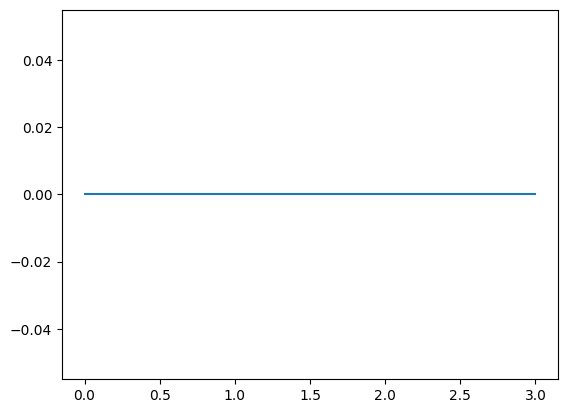

In [21]:
import matplotlib.pyplot as plt
plt.plot(cat_states[0,0,:], cat_states[1,0,:])
# plt.plot(cat_states[1,0,:])

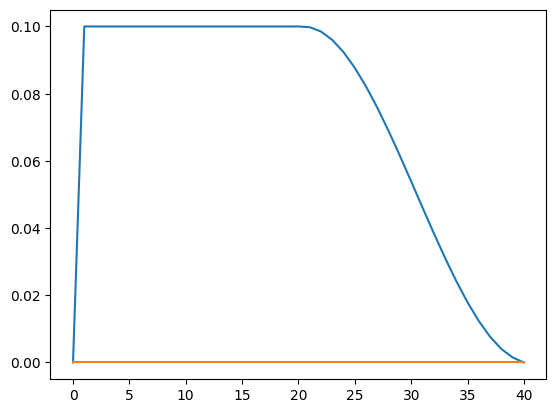

In [22]:
plt.plot(cat_controls[0,0,:])#, cat_states[1,0,:])
plt.plot(cat_controls[1,0,:])

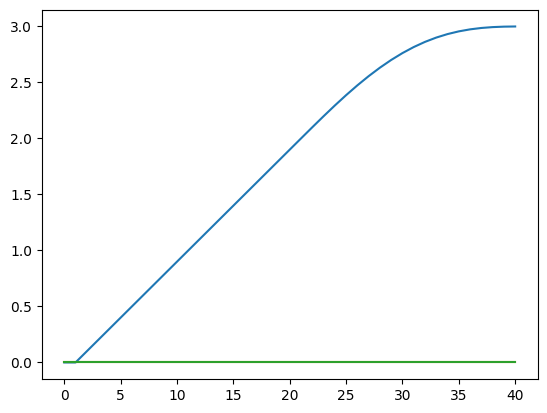

In [18]:
plt.plot(cat_states[0,0,:])
plt.plot(cat_states[1,0,:])
plt.plot(cat_states[2,0,:])